# Programming assignment 2: Random forests
Group 23

Sergi Cases & Martí Pascual

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

## Task 1: Working with a dataset with categorical features

In [2]:
train_df = pd.read_csv("adult_train.csv")
test_df = pd.read_csv("adult_test.csv")

print(train_df.shape, test_df.shape)
train_df.head()

(32561, 14) (16281, 14)


,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,27,Private,Some-college,10,Divorced,Adm-clerical,Unmarried,White,Female,0,0,44,United-States,<=50K
1,27,Private,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,40,United-States,<=50K
2,25,Private,Assoc-acdm,12,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States,<=50K
3,46,Private,5th-6th,3,Married-civ-spouse,Transport-moving,Husband,Amer-Indian-Eskimo,Male,0,1902,40,United-States,<=50K
4,45,Private,11th,7,Divorced,Transport-moving,Not-in-family,White,Male,0,2824,76,United-States,>50K


In [3]:
X_train_df = train_df.drop(columns=["target"])
y_train = train_df["target"]

X_test_df = test_df.drop(columns=["target"])
y_test = test_df["target"]

print("Train:", X_train_df.shape, "Test:", X_test_df.shape)

Train: (32561, 13) Test: (16281, 13)


In [4]:
train_dicts = X_train_df.to_dict("records")
test_dicts = X_test_df.to_dict("records")

dv = DictVectorizer()
X_train_encoded = dv.fit_transform(train_dicts)
X_test_encoded = dv.transform(test_dicts)

print("Encoded train shape:", X_train_encoded.shape)

Encoded train shape: (32561, 107)


In [5]:
dt = DecisionTreeClassifier(random_state=42)
cv_scores = cross_val_score(dt, X_train_encoded, y_train, cv=5, scoring="accuracy")
print(f"CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

CV Accuracy: 0.8180 (+/- 0.0034)


In [6]:
dt.fit(X_train_encoded, y_train)
test_acc = dt.score(X_test_encoded, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8182


In [7]:
pipeline = make_pipeline(
    DictVectorizer(),
    DecisionTreeClassifier(random_state=42)
)

pipeline.fit(train_dicts, y_train)
print(f"Pipeline Test Accuracy: {pipeline.score(test_dicts, y_test):.4f}")

Pipeline Test Accuracy: 0.8182


## Task 2: Decision trees and random forests

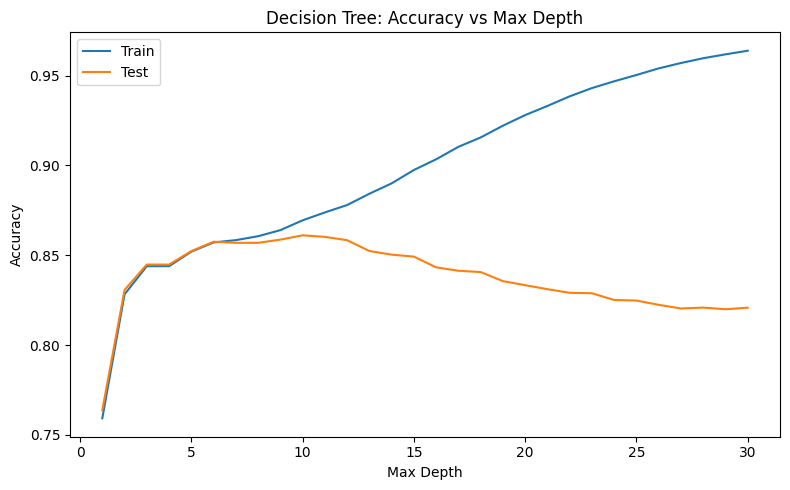

In [8]:
depths = list(range(1, 31))
train_accs_dt = []
test_accs_dt = []

for d in depths:
    clf = make_pipeline(DictVectorizer(), DecisionTreeClassifier(max_depth=d, random_state=42))
    clf.fit(train_dicts, y_train)
    train_accs_dt.append(clf.score(train_dicts, y_train))
    test_accs_dt.append(clf.score(test_dicts, y_test))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_accs_dt, label="Train")
plt.plot(depths, test_accs_dt, label="Test")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Accuracy vs Max Depth")
plt.legend()
plt.tight_layout()
plt.savefig("dt_overfitting.png", dpi=150)
plt.show()

Yes, we see a similar effect as in the previous task. In both cases, we can observe that at small depths the model is underfitted and does not achieve very high accuracy. In training, the deeper the tree is, the more specialized it becomes to the training data, which can lead to overfitting. Then, in testing, the model may perform worse because it has become too accustomed to the training data and is not able to generalize well to unseen data.

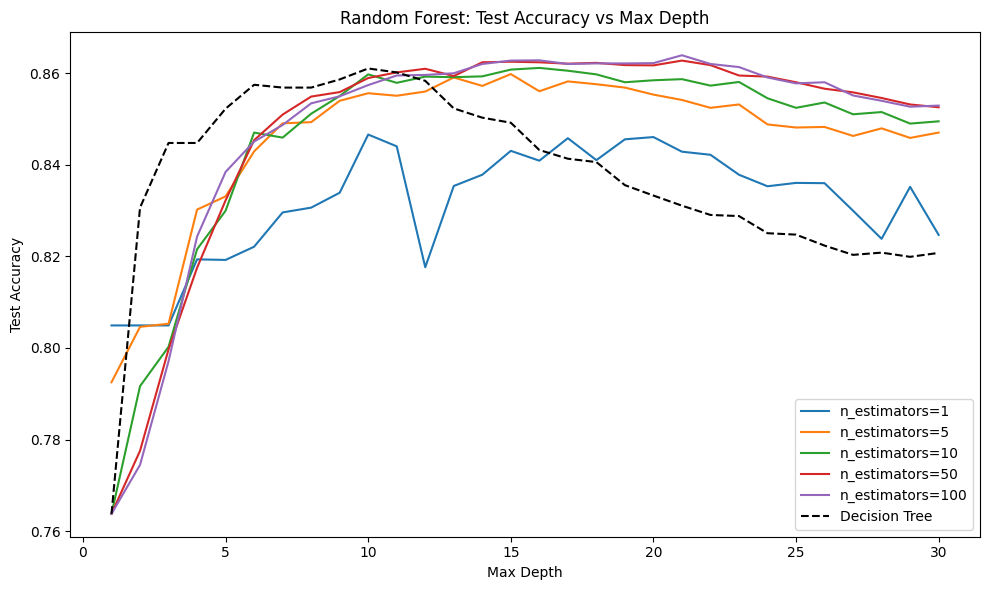

In [ ]:
n_estimators_list = [1, 5, 10, 50, 100]
depths = list(range(1, 31))

plt.figure(figsize=(10, 6))

for n_est in n_estimators_list:
    test_accs_rf = []
    for d in depths:
        clf = make_pipeline(
            DictVectorizer(),
            RandomForestClassifier(n_estimators=n_est, max_depth=d, random_state=42, n_jobs=-1)
        )
        clf.fit(train_dicts, y_train)
        test_accs_rf.append(clf.score(test_dicts, y_test))
    plt.plot(depths, test_accs_rf, label=f"n_estimators={n_est}")

plt.plot(depths, test_accs_dt, label="Decision Tree", linestyle="--", color="black")
plt.xlabel("Max Depth")
plt.ylabel("Test Accuracy")
plt.title("Random Forest: Test Accuracy vs Max Depth")
plt.legend()
plt.tight_layout()
plt.savefig("rf_overfitting.png", dpi=150)
plt.show()

n_estimators=1: 1.38s, test acc=0.8181
n_estimators=5: 1.45s, test acc=0.8390
n_estimators=10: 1.52s, test acc=0.8439
n_estimators=25: 2.58s, test acc=0.8422
n_estimators=50: 3.90s, test acc=0.8452
n_estimators=100: 7.30s, test acc=0.8458
n_estimators=200: 13.70s, test acc=0.8454


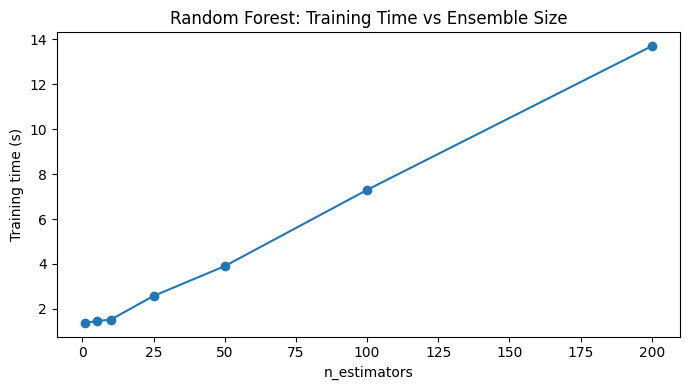

In [10]:
ensemble_sizes = [1, 5, 10, 25, 50, 100, 200]
times = []

for n_est in ensemble_sizes:
    clf = make_pipeline(
        DictVectorizer(),
        RandomForestClassifier(n_estimators=n_est, random_state=42, n_jobs=-1)
    )
    t0 = time.time()
    clf.fit(train_dicts, y_train)
    times.append(time.time() - t0)
    print(f"n_estimators={n_est}: {times[-1]:.2f}s, test acc={clf.score(test_dicts, y_test):.4f}")

plt.figure(figsize=(7, 4))
plt.plot(ensemble_sizes, times, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Training time (s)")
plt.title("Random Forest: Training Time vs Ensemble Size")
plt.tight_layout()
plt.savefig("rf_time.png", dpi=150)
plt.show()

#### What is the difference between the curve for a decision tree and for a random forest with an ensemble size of 1, and why do we see this difference?

A random forest with n_estimators = 1 is still not exactly the same as a normal decision tree, because it uses bootstrap sampling and random feature selection at each split. Because of this extra randomness, its curve is usually a bit noisier and its performance can be slightly worse than a standard decision tree.

#### What happens with the curve for random forests as the ensemble size grows?

As n_estimators increases, the curve becomes smoother and more stable. This happens because the model averages many different trees, which reduces variance and makes the results less sensitive to randomness.

#### What happens with the best observed test set accuracy as the ensemble size grows?

The best test accuracy generally improves at first, but after around 50 to 100 trees the improvement becomes very small, so the gains start to level off.

#### What happens with the training time as the ensemble size grows?

Training time increases approximately linearly with the number of trees, because the model has to train more estimators.

## Task 3: Feature importances in random forest classifiers

In [ ]:
rf_pipeline = make_pipeline(
    DictVectorizer(),
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
)
rf_pipeline.fit(train_dicts, y_train)
print(f"Test Accuracy: {rf_pipeline.score(test_dicts, y_test):.4f}")

dv_step = rf_pipeline.steps[0][1]
rf_step = rf_pipeline.steps[1][1]
feature_names = dv_step.feature_names_
importances = rf_step.feature_importances_

sorted_idx = np.argsort(importances)[::-1]
print("\nTop 15 most important:")
for i in sorted_idx[:15]:
    print(f"  {feature_names[i]:<40} {importances[i]:.4f}")

Test Accuracy: 0.8458

Top 15 most important features:
  age                                      0.2258
  hours-per-week                           0.1153
  capital-gain                             0.1107
  education-num                            0.0613
  marital-status=Married-civ-spouse        0.0594
  relationship=Husband                     0.0478
  capital-loss                             0.0350
  marital-status=Never-married             0.0272
  occupation=Exec-managerial               0.0203
  occupation=Prof-specialty                0.0175
  education=Bachelors                      0.0127
  relationship=Not-in-family               0.0127
  relationship=Own-child                   0.0117
  workclass=Private                        0.0114
  relationship=Wife                        0.0102


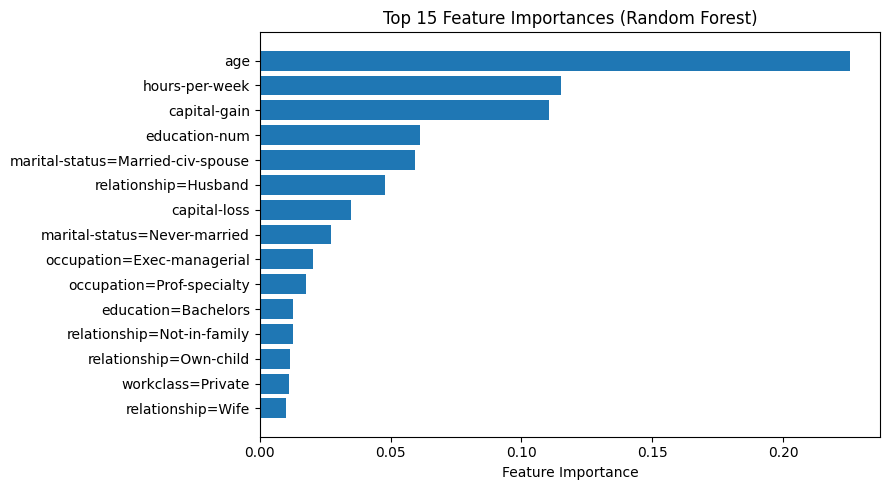

In [12]:
top_n = 15
top_features = [feature_names[i] for i in sorted_idx[:top_n]]
top_scores = [importances[i] for i in sorted_idx[:top_n]]

plt.figure(figsize=(9, 5))
plt.barh(top_features[::-1], top_scores[::-1])
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.savefig("feature_importances.png", dpi=150)
plt.show()


It is clear that the top features align well with intuition about income predictors. Capital gains directly signal wealth, education and hours worked correlate with earning potential.

An alternative is to use the Gini coefficient. In decision trees and random forests, a feature is considered important if it helps reduce Gini impurity a lot when the data is split. The larger the total reduction, the more important the feature is.